# Control and Machine Learning: the big picture

*Introduction to Control and Machine Learning · Notebook 00*

> **Central question.** *What do controlling a dynamical system and training a learning machine have in common?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | 25–35 min |
| **Execution time** | a few seconds |
| **Exercises** | 3 short conceptual questions, ≈ 15 min |
| **Prerequisites** | none |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 1–6, 10–12, 53, 70, 252, 327–329, 336, 338, 384 (see the Source map at the end) |
| **Notation** | `notation.md` |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

**Learning objectives.** After this notebook you should be able to

1. name the three basic control problems and the basic learning problem of the course;
2. read the course map and place each notebook on it;
3. use the control ↔ machine-learning dictionary, and say which correspondences are exact and which are only analogies;
4. recognize the three recurring examples E1, E3 and E6;
5. find your way through the `CORE` / `DEEPER LOOK` / `RESEARCH WINDOW` layers.

## 1. What is the course trying to connect?
`CORE`

**Control.** A system has a *state* that evolves according to a law, the *state equation*, in which we can act through a *control*. The goal is to drive the state close to a desired one (PDF p. 10). The slides distinguish three questions (p. 12):

- **optimal control:** which admissible control minimizes a cost, such as the distance to a target?
- **controllability:** can the state be driven *exactly* to a prescribed target?
- **stabilization / feedback:** can we find a rule $u=F(x)$, computed in real time from the state, that drives the system towards equilibrium?

**Machine learning.** A model with parameters $w$ is fitted to data by minimizing a loss $F(w)$, with the aim of making good predictions on *unobserved* data (p. 252).

**Where they meet.** The slides place three formulas side by side (p. 327):

$$
x'(t)=w(t)\,\sigma\big(a(t)\cdot x(t)+b(t)\big),\qquad
x_{k+1}=x_k+h\,w_k\,\sigma(a_k\cdot x_k+b_k),\qquad
f(x)\approx\sum_{j=1}^{K}w_j\,\sigma(a_j\cdot x+b_j).
$$

They are related, not identical. The first is a **controlled dynamical system** (a *neural ODE*): a neuron $w\,\sigma(a\cdot x+b)$ is used as the vector field, and the parameters $(w,a,b)$ act as controls. The second is one step of the explicit Euler method for it, and it is exactly the layer of a **residual neural network (ResNet)**. The third is a **shallow network**: it evaluates a sum of features at the *same* input $x$, so it is in general neither a composition of layers nor a trajectory. For the two dynamical models, training means choosing the controls that minimize a cost along the trajectories of the data points (p. 328).

The course therefore runs along one line: first control (Part I), then optimization and adjoints (Part II), then machine learning (Part III), and finally the fusion of the two (Part IV). The objectives of the fusion, as stated on p. 329, include explainability, generalization, robustness and complexity.

## 2. The map of the course
`CORE`

```
CONTROL
  │  state + dynamics + control ................................. 01, 02
  │  controllability · observability · feedback ................. 02, 03, 04, 05
  │  optimization + adjoints ..................................... 06, 07
  │  long horizons, gradient dynamics ............................ 06, 08
MACHINE LEARNING
  │  learning from data; training ≠ generalization ............... 09
  │  training algorithms: GD, SGD, momentum, Adam ................ 10, 11
NEURAL NETWORKS AS DYNAMICAL SYSTEMS
  │  shallow networks; ResNets = discretized controlled ODEs ..... 12, 13
  │  classification as simultaneous control ...................... 14
  │  transformers · neural transport ............................. 15, 16
SYNTHESIS ........................................................ 17
```

| Part | Notebooks |
|---|---|
| — | 00 *this map* |
| I. Control | [01 What is control?](01_control_fundamentals.ipynb) · [02 Linear control and the Kalman condition](02_linear_control_kalman.ipynb) · [03 Observability, duality and the construction of controls](03_observability_duality_adjoints.ipynb) · [04 Bang-bang and switching controls](04_structured_controls_bangbang_switching.ipynb) · [05 Feedback stabilization](05_feedback_stabilization.ipynb) |
| II. Optimization and long-time control | [06 Minimizers, gradient flows and gradient descent](06_variational_principles_gradient_flows.ipynb) · [07 Adjoint methods and the heat equation](07_adjoints_density_heat_control.ipynb) · [08 Turnpike](08_long_time_control_turnpike.ipynb) |
| III. Machine learning | [09 Learning from data and generalization](09_machine_learning_foundations_generalization.ipynb) · [10 GD and SGD](10_training_gd_sgd.ipynb) · [11 Momentum and adaptive methods](11_optimization_algorithms_ml.ipynb) |
| IV. Fusion | [12 Shallow networks](12_shallow_networks_representation_sparsity.ipynb) · [13 ResNets and neural ODEs](13_resnets_neural_odes.ipynb) · [14 Classification as simultaneous control](14_classification_as_simultaneous_control.ipynb) · [15 Transformers](15_transformers_as_dynamics.ipynb) · [16 Neural transport](16_neural_transport.ipynb) |
| — | [17 Control and learning: a synthesis of connections and limits](17_synthesis_control_and_learning.ipynb) |

Three threads run through the whole map:

- **adjoints:** Lagrange multipliers → adjoint system → adjoint method → backpropagation;
- **gradient dynamics:** gradient flow → gradient descent → stochastic gradient descent → momentum;
- **controllability → expressivity:** steering one system → steering many data points with one shared control.

## 3. A minimal dictionary
`CORE`

The table translates the basic words of control into machine learning. **"Exact"** means that, within the model stated in the last column, the two sides are the same mathematical object. **"Analogy"** means a useful parallel with a genuine difference, which is explained.

| Control | Machine learning | Status | In which model, and where |
|---|---|---|---|
| state $x(t)$ | representation (feature vector) of a data point at depth $t$ | **exact** | neural ODE / ResNet: the data point is the initial state (pp. 327, 336) |
| control $u(t)$ | trainable parameters $(w(t),a(t),b(t))$ | **exact** | neural ODE (pp. 327–328) |
| trajectory | forward propagation | **exact** | ResNet: the forward pass computes the Euler trajectory (p. 327) |
| time $t$ | depth | **exact**, with a caveat | ResNet with step $h$: layer $k$ ↔ time $kh$. In an Euler discretization every step is a layer, whether or not the weights are shared between steps. The number of time steps, the number of pieces on which the control is constant, and the number of independent parameter sets are three different counts |
| cost $J$ | loss (empirical risk) | **exact** | training written as minimizing a cost along trajectories (p. 328) |
| adjoint state | backward sensitivity (backpropagation) | **exact** as a mathematical identity, *not stated in the slides* | the slides say backpropagation is reverse-mode differentiation (p. 53); the identity with a discrete adjoint system is shown in notebook 03 (sensitivity) and [notebook 13](13_resnets_neural_odes.ipynb) |
| target $x^1$ | desired prediction (label) | **analogy** | in classification the target is a *region* attached to each label (p. 338), and the prediction is read off the final state; there is no single target point |
| feedback $u=F(x)$ | adaptive action, reinforcement learning | **analogy** | reinforcement learning is "learning based on feedback" through rewards (p. 70); it learns a policy, which is not the same object as a feedback law designed from a known model |

Two warnings. First, the dictionary works because of one modelling choice, reading a network as a controlled ODE; it is not a statement about all of machine learning. Second, "training" adds an axis that the classical control framework of this course does not treat: the result must work on data *not* used to choose the controls (generalization, [notebook 09](09_machine_learning_foundations_generalization.ipynb)). Control theory has its own theories of robustness and uncertainty, which this course does not develop.

## 4. How the notebooks are built
`CORE`

Every notebook has the same skeleton, so that you always know where you are:

- a **central question**, a "**Where are we?**" recap and learning objectives;
- the argument, with results stated as *Assumptions / Conclusion / Interpretation* and proofs ending in $\square$;
- **prediction questions** before computations ("before running the cell, what do you expect?");
- figures, each followed by a caption `Figure n.` and an interpretation;
- common misconceptions, a short list "What you should remember", and exercises ★ (conceptual), ★★ (mathematical), ★★★ (computational, with a `# TODO: student exercise` cell);
- "**Where are we going?**" and a **Source map** to the PDF pages of the slides, which remain the authoritative source.

The three **layers** let you choose the depth of reading:

| Layer | What it contains | Can I skip it? |
|---|---|---|
| `CORE` | the main line of the argument | no |
| `DEEPER LOOK` | proofs of secondary facts, finer comparisons, optional checks | yes |
| `RESEARCH WINDOW` | recent or advanced results from the slides, open questions | yes |

Solutions to the exercises are kept in a separate instructor version.

## 5. Three recurring examples
`CORE`

A few examples return throughout the course, so that each notebook adds a new view of a familiar object instead of a new toy.

- **E1, the harmonic oscillator**, $x_1''+x_1=u$, with state $x=(x_1,x_2)=(\text{position},\text{velocity})$. It is controlled (02, 03), damped (01), stabilized by feedback (05) and optimized over long horizons (08); its closed loop under $u=-x_1-3x_2$ is learned from data (16).
- **E3, a quadratic landscape**, $J(u)=\tfrac12u^\top Qu-q^\top u$ with $Q$ symmetric positive definite. It is the simplest setting for gradient descent and its relatives (06, 10, 11). The functional that produces controls in notebook 03 is exactly of this form.
- **E6, a point cloud** of two classes in the plane. It is classified (09–11) and steered by neural ODEs (13–14). The other notebooks of Part IV use their own examples: 12 a one-dimensional regression example (E9), 15 toy tokens (E7), and 16 a transported distribution (E8) together with the E1 closed loop.

> **Predict.** In the next figure, the right panel moves the E6 points with the vector field $x'=w\,\sigma(a\cdot x+b)$, where $\sigma(z)=\max\{z,0\}$, for fixed $a,b,w$. Which points do you expect to move, and which to stay where they are?

The single computation of this notebook integrates two ODEs of the same form $x'=F(x,\text{control})$.

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from src.control_utils import harmonic_oscillator, simulate
from src.ml_utils import point_cloud_E6
from src.plotting_utils import apply_style, COLORS

apply_style()
rng = np.random.default_rng(seed=0)        # the only source of randomness in this notebook

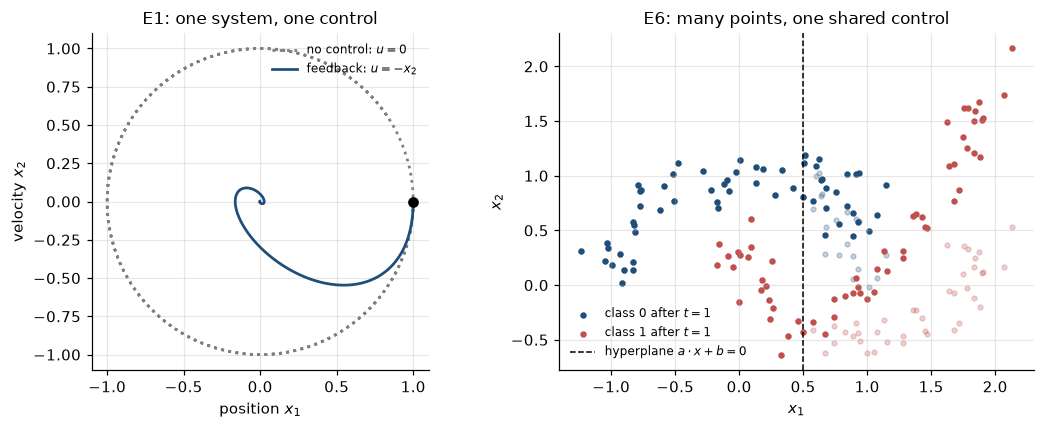

In [2]:
# Left: E1 without control, and with the feedback u = -x2 (damping).
A, B = harmonic_oscillator()
t = np.linspace(0, 12, 600)
x0 = np.array([1.0, 0.0])
free = simulate(A, B, lambda s: np.zeros(1), x0, 12, t)
damped = simulate(A - B @ np.array([[0.0, 1.0]]), B, lambda s: np.zeros(1), x0, 12, t)   # u = -x2

# Right: E6 moved by the ReLU field x' = w * relu(a.x + b), with fixed (w, a, b).
X, y = point_cloud_E6(rng)
a, b, w = np.array([1.0, 0.0]), -0.5, np.array([0.0, 1.0])


def relu_field(s, z):
    pts = z.reshape(-1, 2)
    return (np.maximum(pts @ a + b, 0.0)[:, None] * w).ravel()


X_end = solve_ivp(relu_field, (0, 1.0), X.ravel(), rtol=1e-8, atol=1e-10).y[:, -1].reshape(-1, 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(free[:, 0], free[:, 1], ":", color=COLORS["reference"], label="no control: $u=0$")
ax1.plot(damped[:, 0], damped[:, 1], color=COLORS["state"], label="feedback: $u=-x_2$")
ax1.plot(*x0, "o", color="black")
ax1.set_xlabel("position $x_1$"); ax1.set_ylabel("velocity $x_2$"); ax1.set_aspect("equal")
ax1.set_title("E1: one system, one control"); ax1.legend(loc="upper right", fontsize=8)

for label, color in ((0, COLORS["state"]), (1, COLORS["control"])):
    ax2.scatter(*X[y == label].T, s=10, color=color, alpha=0.25)
    ax2.scatter(*X_end[y == label].T, s=10, color=color, label=f"class {label} after $t=1$")
ax2.axvline(-b, color="black", lw=1, ls="--", label=r"hyperplane $a\cdot x+b=0$")
ax2.set_xlabel("$x_1$"); ax2.set_ylabel("$x_2$")
ax2.set_title("E6: many points, one shared control"); ax2.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

**Figure 1.** *Left:* E1 in the phase plane from $x^0=(1,0)$. Without control the energy $\tfrac12|x|^2$ is conserved (dotted circle). With the feedback $u=-x_2$ the state spirals into the equilibrium. *Right:* the E6 point cloud (faint: initial positions; solid: positions at $t=1$) under the field $x'=w\,\sigma(a\cdot x+b)$ with $a=(1,0)$, $b=-0.5$, $w=(0,1)$.

*Interpretation (answer to the prediction).* The ReLU activates the half-plane $a\cdot x+b>0$, to the right of the dashed line, and freezes the other one. Only the points on the right move, in the direction $w$, faster the farther they are from the line. The left panel shows the classical situation of control: one system, steered by its own control (notebooks 01–05). The right panel shows the situation of machine learning read as control: **many states, one shared control**. Classification by such elementary moves is the subject of [notebook 14](14_classification_as_simultaneous_control.ipynb).

## 6. Exercises

★ conceptual. Reference answers are kept in the instructor version.

**Exercise 1 ★ (exact or analogy?).** Decide whether each correspondence is exact or only an analogy, and say in which model: (a) learning rate ↔ time step of a gradient flow; (b) training set ↔ set of initial states; (c) regularization term $\alpha\int_0^T\|(a,w,b)\|^2dt$ ↔ cost of the control.

**Exercise 2 ★ (which problem is it?).** Classify each task as optimal control, controllability, stabilization, or a learning problem (supervised, unsupervised, reinforcement): (a) a thermostat keeps a room at 21 °C; (b) a satellite must reach a given orientation at a given time; (c) a drone must reach a point while using as little energy as possible; (d) a program learns to play a game from wins and losses; (e) a program learns to recognize handwritten digits from labelled examples.

**Exercise 3 ★ (finding your way).** Using the map in §2, which notebook would you open first to answer: (a) "When can a linear system be steered anywhere?"; (b) "Why can more damping make a system return to rest *more slowly*?"; (c) "Why does an adjoint system appear when we construct controls?"

## Where are we going?
`CORE`

[Notebook 01](01_control_fundamentals.ipynb) starts the mathematics. It makes the three control problems of §1 precise, introduces feedback, and meets the first surprise of the course: more damping does not always mean faster return to rest.

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`. The machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| §1 Control problems | 10–12 | State equation, control, target; optimal control, controllability, feedback |
| §1 Machine learning | 252 | Parameters, loss, minimization, prediction on unobserved data |
| §1 Neural ODE, ResNet, shallow network | 327–329 | The three formulas; training as a cost along trajectories; objectives |
| §2 Map | 1–6, 384 | Table of contents; conclusions and perspectives |
| §3 Dictionary | 53, 70, 327–328, 336, 338 | Backpropagation as reverse-mode differentiation; RL as feedback; NODE; simultaneous control; classification into regions |

**Pedagogical additions:** the map of §2 as a single diagram, the dictionary with its exact/analogy labels, the layer conventions (§4), the recurring examples (§5) and Figure 1.